In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("parking_cleaned.csv")
df.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,DayOfWeek,DayName,IsWeekend,IsPeakHour
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42,0.105719,10.571924,516,2016-10-04,7,59,1,Tuesday,0,0
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42,0.110919,11.091854,513,2016-10-04,8,25,1,Tuesday,0,0
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42,0.138648,13.864818,497,2016-10-04,8,59,1,Tuesday,0,0
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46,0.185442,18.544194,470,2016-10-04,9,32,1,Tuesday,0,1
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48,0.259965,25.996534,427,2016-10-04,9,59,1,Tuesday,0,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 35489
Columns: 14


In [4]:
print("Start date:", df["LastUpdated"].min())
print("End date:", df["LastUpdated"].max())

Start date: 2016-10-04 07:46:28
End date: 2016-12-19 16:30:35


Parking Lot Analysis

In [ ]:
# Q1. Which parking lots are busiest?

lot_demand = (
    df.groupby("SystemCodeNumber")["OccupancyPercent"]
      .mean()
      .sort_values(ascending=False)
)

lot_demand

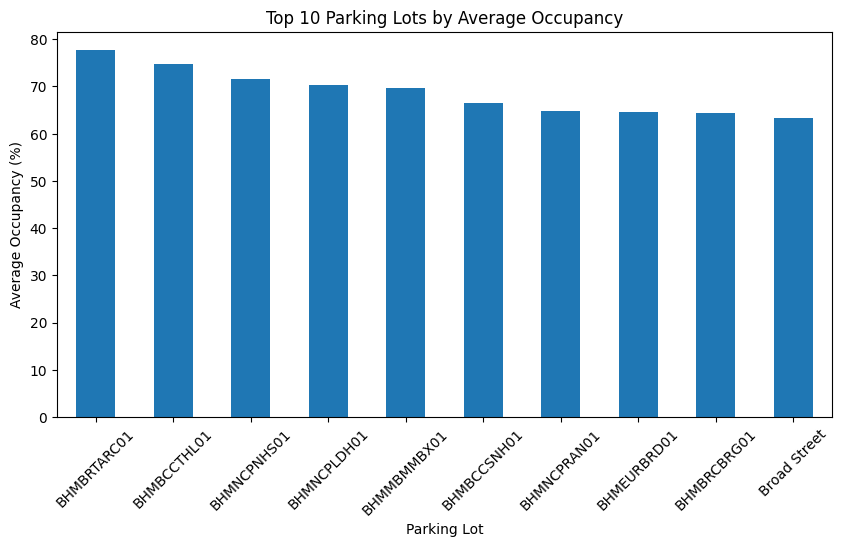

In [8]:
# Top 10 Parking Lots
top_10_lots = lot_demand.head(10)

plt.figure(figsize=(10, 5))

top_10_lots.plot(kind="bar")

plt.xlabel("Parking Lot")
plt.ylabel("Average Occupancy (%)")
plt.title("Top 10 Parking Lots by Average Occupancy")

plt.xticks(rotation=45)

plt.show()

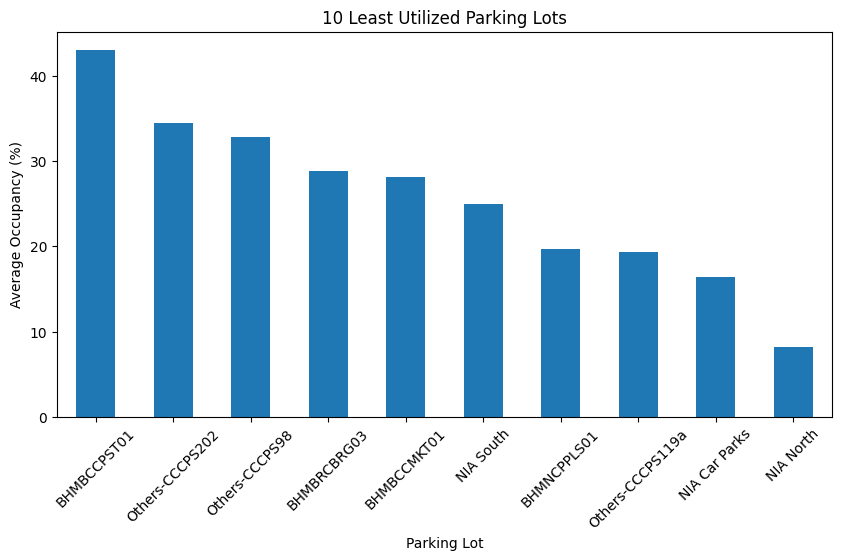

In [9]:
# Least Utilized Lots

bottom_10_lots = lot_demand.tail(10)

plt.figure(figsize=(10, 5))

bottom_10_lots.plot(kind="bar")

plt.xlabel("Parking Lot")
plt.ylabel("Average Occupancy (%)")
plt.title("10 Least Utilized Parking Lots")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Q2. At what time is parking demand highest?

hourly_demand = (df.groupby("Hour")["OccupancyPercent"].mean())
hourly_demand

,OccupancyPercent
Hour,
7,21.087751
8,25.532723
9,37.198720
10,46.624312
11,54.649539
12,59.062685
13,60.570754
14,60.716759
15,56.218678


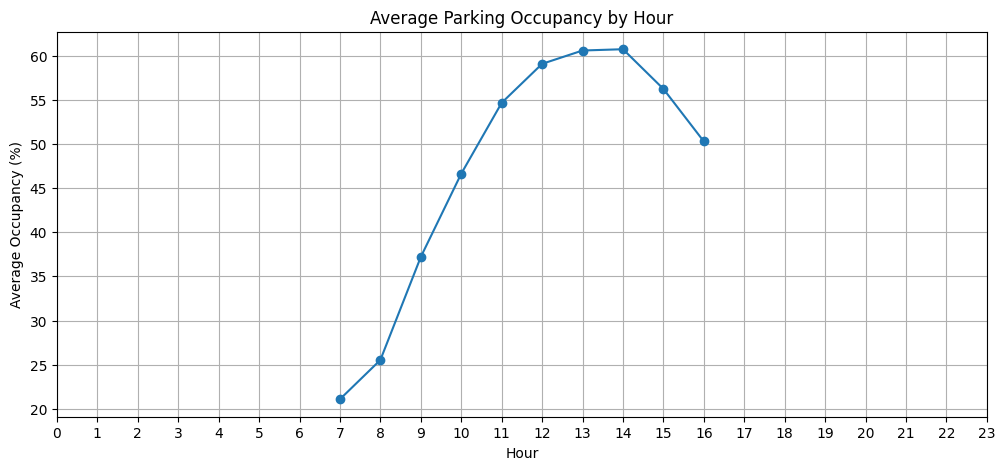

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Average Occupancy (%)")
plt.title("Average Parking Occupancy by Hour")

plt.xticks(range(24))

plt.grid()

plt.show()

In [13]:
# Exact Peak Hour

peak_hour = hourly_demand.idxmax()
peak_occupancy = hourly_demand.max()

print("Peak hour:", peak_hour)
print("Average occupancy:", peak_occupancy)

Peak hour: 14
Average occupancy: 60.71675899249722


In [14]:
print(
    f"Peak parking demand occurs around {peak_hour}:00 "
    f"with average occupancy of {peak_occupancy:.2f}%."
)

Peak parking demand occurs around 14:00 with average occupancy of 60.72%.


In [15]:
# Is parking demand different on different days?

day_demand = (df.groupby("DayName")["OccupancyPercent"].mean())


In [16]:
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["DayName"] = pd.Categorical(
    df["DayName"],
    categories=days,
    ordered=True
)

In [17]:
day_demand = (
    df.groupby(
        "DayName",
        observed=True
    )["OccupancyPercent"]
    .mean()
)

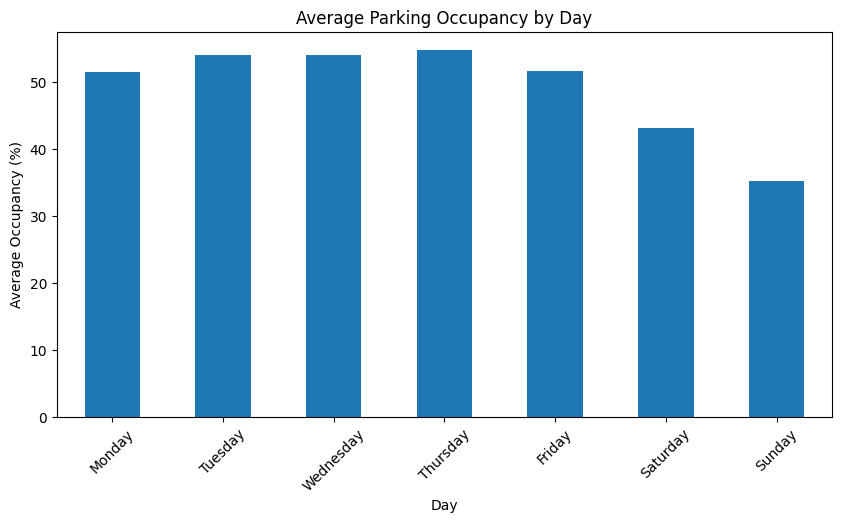

In [18]:
plt.figure(figsize=(10, 5))

day_demand.plot(kind="bar")

plt.xlabel("Day")
plt.ylabel("Average Occupancy (%)")
plt.title("Average Parking Occupancy by Day")

plt.xticks(rotation=45)

plt.show()

In [23]:
weekend_comparison = (
    df.groupby("IsWeekend")["OccupancyPercent"]
      .mean()
)

weekend_comparison

,OccupancyPercent
IsWeekend,
0,53.215615
1,39.237359


In [24]:
weekend_comparison.index = [
    "Weekday",
    "Weekend"
]

weekend_comparison

,OccupancyPercent
Weekday,53.215615
Weekend,39.237359


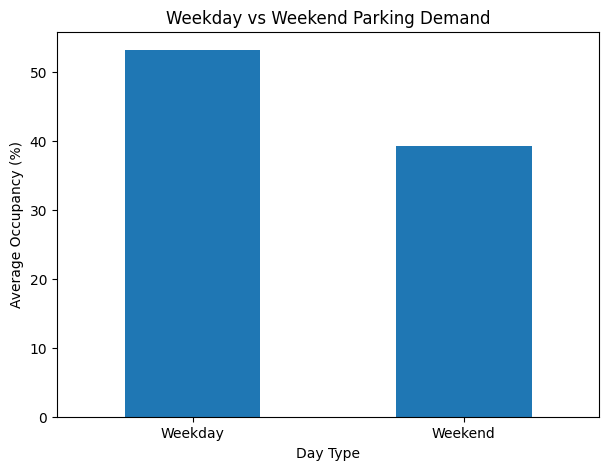

In [25]:
plt.figure(figsize=(7, 5))

weekend_comparison.plot(kind="bar")

plt.xlabel("Day Type")
plt.ylabel("Average Occupancy (%)")
plt.title("Weekday vs Weekend Parking Demand")

plt.xticks(rotation=0)

plt.show()

In [27]:
# Demand Heatmap
heatmap_data = df.pivot_table(
    index="DayName",
    columns="Hour",
    values="OccupancyPercent",
    aggfunc="mean",
    observed=True
)

heatmap_data = heatmap_data.reindex(days)

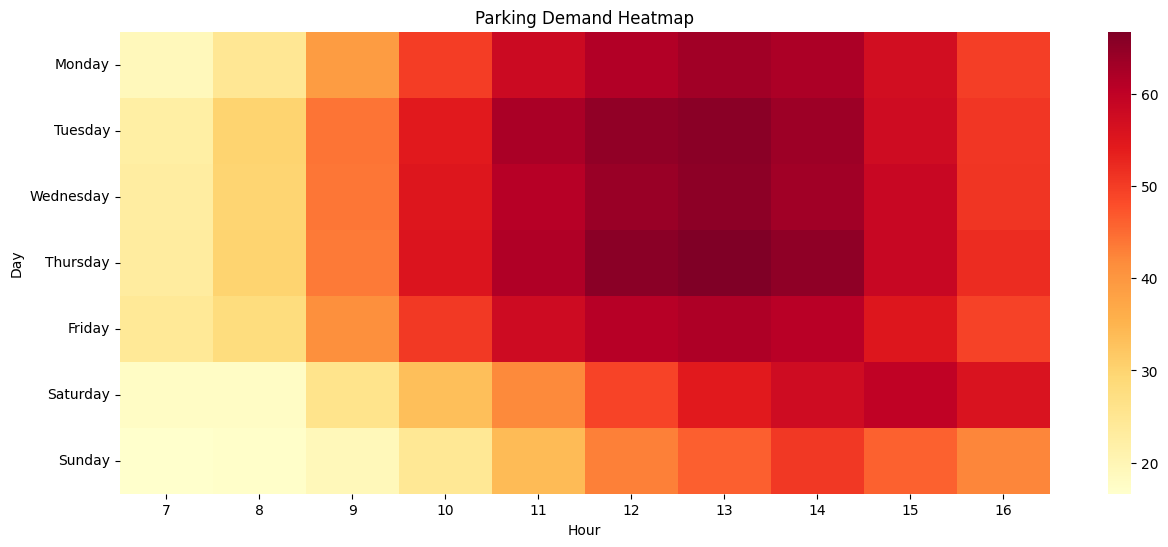

In [30]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Parking Demand Heatmap")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

In [31]:
# Utilization Categories

def classify_demand(occupancy):

    if occupancy < 30:
        return "Low"

    elif occupancy < 60:
        return "Moderate"

    elif occupancy < 80:
        return "High"

    else:
        return "Critical"

In [32]:
df["DemandLevel"] = df["OccupancyPercent"].apply(classify_demand)

In [33]:
df["DemandLevel"].value_counts()

,count
DemandLevel,
Moderate,11399
Low,10762
High,7254
Critical,6074


In [34]:
df["DemandLevel"].value_counts(normalize=True) * 100

,proportion
DemandLevel,
Moderate,32.119812
Low,30.324889
High,20.440136
Critical,17.115162


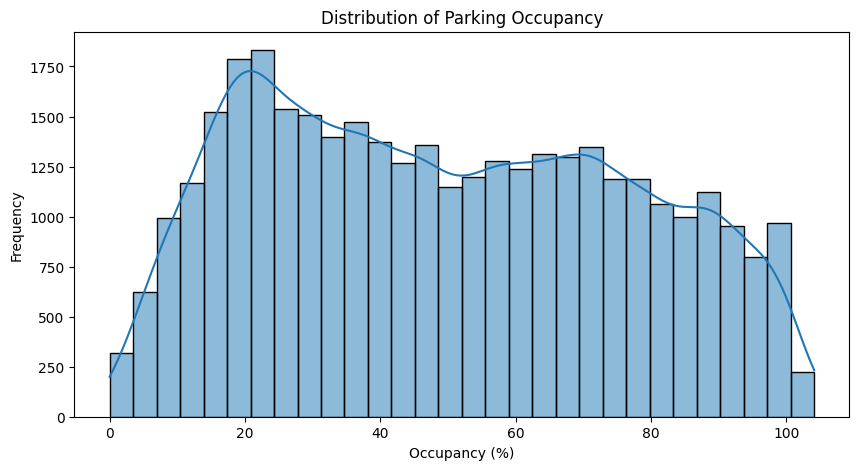

In [35]:
# Demand Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df["OccupancyPercent"],
    bins=30,
    kde=True
)

plt.xlabel("Occupancy (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Parking Occupancy")

plt.show()


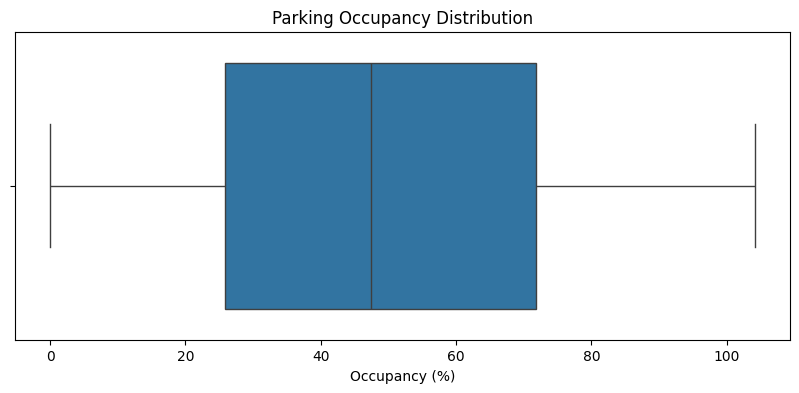

In [36]:
# Boxplot for Occupancy

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["OccupancyPercent"]
)

plt.xlabel("Occupancy (%)")
plt.title("Parking Occupancy Distribution")

plt.show()

In [38]:
# summary of parking lot

lot_summary = (
    df.groupby("SystemCodeNumber")
      .agg(
          AvgOccupancy=("OccupancyPercent", "mean"),
          MaxOccupancy=("OccupancyPercent", "max"),
          MinOccupancy=("OccupancyPercent", "min"),
          AvgAvailableSpaces=("AvailableSpaces", "mean"),
          Capacity=("Capacity", "first")
      )
      .sort_values(
          "AvgOccupancy",
          ascending=False
      )
)

lot_summary

,AvgOccupancy,MaxOccupancy,MinOccupancy,AvgAvailableSpaces,Capacity
SystemCodeNumber,,,,,
BHMBRTARC01,77.664498,84.072581,70.967742,110.784091,496
BHMBCCTHL01,74.695389,104.134367,10.077519,97.928845,387
BHMNCPNHS01,71.580739,100.600000,4.000000,142.096304,500
BHMNCPLDH01,70.394332,100.416667,21.666667,213.160812,720
BHMMBMMBX01,69.577095,100.145560,24.745269,209.005356,687
BHMBCCSNH01,66.458320,100.695249,7.879490,289.464701,863
BHMNCPRAN01,64.901476,99.833333,7.666667,210.591141,600
BHMEURBRD01,64.551008,100.000000,5.957447,166.610260,470
BHMBRCBRG01,64.391622,100.297030,0.000000,359.644614,1010


In [39]:
df.to_csv(
    "parking_cleaned1.csv",
    index=False
)